# Images EDA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
from tqdm import tqdm
import random
import warnings
import imagehash
import math
from collections import Counter


In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
# Load paths from .env file
data_dir = os.getenv("DATA_DIR")
images_dir = os.getenv("IMAGES_DIR")

# Load the unified TSV file
annotations_file = os.path.join(data_dir, "annotations.tsv")

In [59]:
df = pd.read_csv(annotations_file, sep="\t")

In [5]:
print(os.listdir(images_dir))

['california_wildfires', 'hurricane_harvey', 'hurricane_irma', 'hurricane_maria', 'iraq_iran_earthquake', 'mexico_earthquake', 'srilanka_floods']


In [6]:
print(os.listdir(images_dir + "/california_wildfires"))

['10_10_2017', '11_10_2017', '12_10_2017', '15_10_2017', '16_10_2017', '17_10_2017', '18_10_2017', '19_10_2017', '20_10_2017', '21_10_2017', '22_10_2017', '23_10_2017', '24_10_2017', '25_10_2017', '26_10_2017', '27_10_2017']


In [7]:
print(os.listdir(images_dir + "/california_wildfires/10_10_2017"))

['._917791044158185473_0.jpg', '._917793736918216706_0.jpg', '._917821459321556992_0.jpg', '._917825152636907523_0.jpg', '._917827226372132864_0.jpg', '._917830092620836864_0.jpg', '._917851921943318528_0.jpg', '917791044158185473_0.jpg', '917791130590183424_0.jpg', '917791291823591425_0.jpg', '917791291823591425_1.jpg', '917792092100988929_0.jpg', '917792147700465664_0.jpg', '917792930315821057_0.jpg', '917793137925459968_0.jpg', '917793137925459968_1.jpg', '917793137925459968_2.jpg', '917793158251077632_0.jpg', '917793736918216706_0.jpg', '917793881533571073_0.jpg', '917794024173563904_0.jpg', '917794232160661505_0.jpg', '917794360581869569_0.jpg', '917794580728295424_0.jpg', '917794892113498113_0.jpg', '917795098523512962_0.jpg', '917795236595863552_0.jpg', '917796280377602048_0.jpg', '917796307191951360_0.jpg', '917796883610820608_0.jpg', '917796940900982786_0.jpg', '917797601763889160_0.jpg', '917797763282214913_0.jpg', '917800657796595715_0.jpg', '917803185317859329_0.jpg', '9178

Image Label Task 1: informative
Image Label Confidence: 1.0

Image Label Task 2: infrastructure_and_utility_damage
Image Label Confidence: 1.0

Image Label Task 3: severe_damage
Image Label Confidence: 0.6549


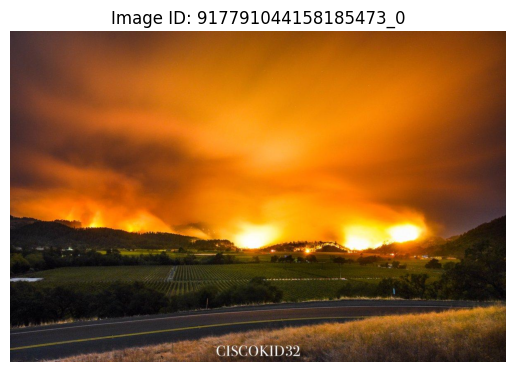

In [8]:
random_row = df.iloc[100]
image_path = random_row["image_path"]

# Open and display the image
image = Image.open("../" + image_path)

print(f'Image Label Task 1: {random_row["image_info"]}')
print(f'Image Label Confidence: {random_row["image_info_conf"]}')
print(f'\nImage Label Task 2: {random_row["image_human"]}')
print(f'Image Label Confidence: {random_row["image_human_conf"]}')
print(f'\nImage Label Task 3: {random_row["image_damage"]}')
print(f'Image Label Confidence: {random_row["image_damage_conf"]}')

plt.imshow(image)
plt.axis('off')
plt.title(f"Image ID: {df.iloc[0]['image_id']}")
plt.show()


## Distribuzione della shape delle immagini

In [9]:
# Inizializza le liste
widths = []
heights = []
aspect_ratios = []
missing = []

# iteration on each image
for idx, row in tqdm(df.iterrows(), total=len(df)):
    image_path = row["image_path"]

    try:
        with Image.open("../" + image_path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
            aspect_ratios.append(w / h)
    except Exception as e:
        #for missing images
        missing.append(row["image_path"])
        widths.append(None)
        heights.append(None)
        aspect_ratios.append(None)

#Added to the dataframe
df["img_width"] = widths
df["img_height"] = heights
df["img_aspect_ratio"] = aspect_ratios


100%|██████████| 18082/18082 [00:18<00:00, 961.31it/s] 


In [10]:
print(f"Missing images: {len(missing)}")

print(f'{len(df["img_width"].unique())} Different width values')
print(f'{len(df["img_height"].unique())} Different height values')
print(f'{len(df["img_aspect_ratio"].unique())} Different aspect ratio values')


Missing images: 0
949 Different width values
1037 Different height values
4728 Different aspect ratio values


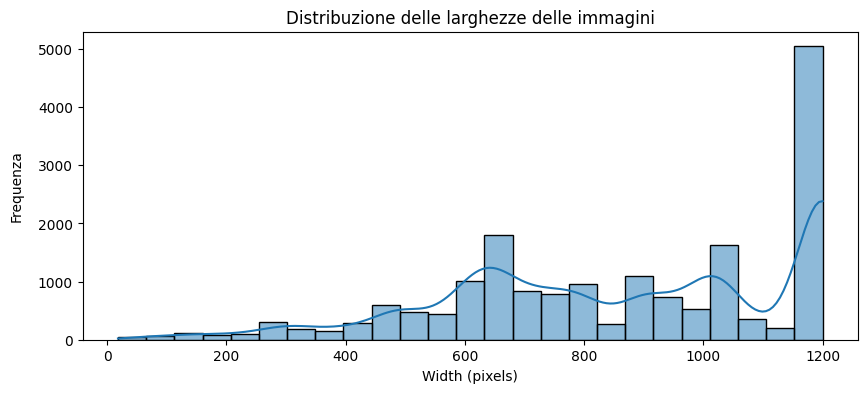

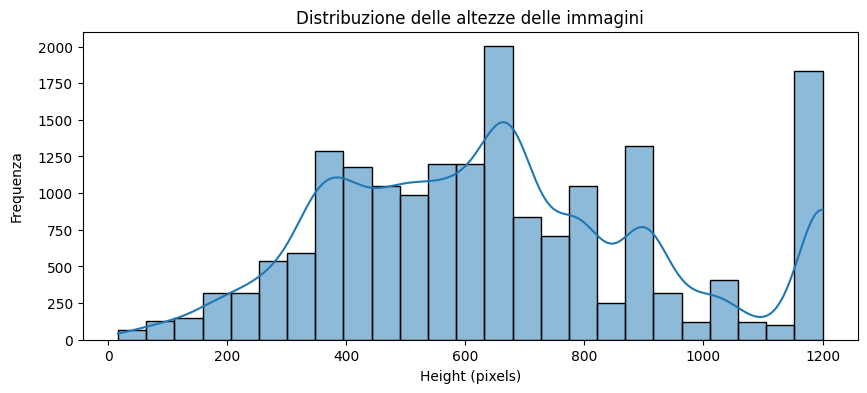

In [11]:
# Istogramma della larghezza
plt.figure(figsize=(10, 4))
sns.histplot(df['img_width'], bins=25, kde=True)
plt.title('Distribuzione delle larghezze delle immagini')
plt.xlabel('Width (pixels)')
plt.ylabel('Frequenza', labelpad=10)
plt.show()

# Istogramma dell'altezza
plt.figure(figsize=(10, 4))
sns.histplot(df['img_height'], bins=25, kde=True)
plt.title('Distribuzione delle altezze delle immagini')
plt.xlabel('Height (pixels)')
plt.ylabel('Frequenza', labelpad=10)
plt.show()


## Relazione tra Tweet e Immagini

In [12]:
n_tweets = len(df["tweet_id"].unique())
n_image = len(df["image_path"].unique())

top_tweets = (
    df.groupby("tweet_id")["image_path"]
    .count()
    .sort_values(ascending=False)
)

# Filtra quelli con più di 1 immagine
top_tweets = top_tweets[top_tweets > 1]

print(f"{str(n_tweets)} total tweets")
print(f"{str(n_image)} total images")
print(f"{len(top_tweets)} tweet hanno più di un immagine associata")
top_tweets


16058 total tweets
18082 total images
1145 tweet hanno più di un immagine associata


tweet_id
931493766816559104    4
869972354004393987    4
904221556938825729    4
904581253629804544    4
930058600160088065    4
                     ..
871734745394102272    2
914701520066813952    2
904623406133501953    2
904572280981790720    2
904528383903621121    2
Name: image_path, Length: 1145, dtype: int64

## Funzioni di plotting

In [13]:
sns.set(style="whitegrid")  # stile seaborn
warnings.filterwarnings("ignore", category=FutureWarning)

# Funzione 1: Barplot migliorato
def plot_label_distribution(df, label_col, title=None):
    label_counts = df[label_col].value_counts()
    n_labels = len(label_counts)

    plt.figure(figsize=(7, 5) if n_labels == 2 else (10, 6))
    width = 0.5 if n_labels == 2 else 0.8
    ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis", width=width)

    plt.title(title or f"Label Distribution: {label_col}", fontsize=16, fontweight='bold')
    plt.xlabel(label_col.replace("_", " ").title(), fontsize=12, fontweight='bold')
    plt.ylabel("Number of Images", fontsize=12, labelpad=20, fontweight='bold')

    if n_labels > 2:
         plt.xticks(rotation=30, ha='right', fontsize=10)
    else:
         plt.xticks(rotation=0, fontsize=10)
    
    for i, count in enumerate(label_counts.values):
        ax.text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=9, fontweight='bold')

    sns.despine()
    plt.tight_layout()
    plt.show()


# Funzione 2: Griglia immagini migliorata per ogni label
def show_one_image_per_label(df, label_col, image_root="data_image", random_seed=42, resize_to=(224, 224)):
    unique_labels = sorted(df[label_col].dropna().unique())
    random.seed(random_seed)

    n_labels = len(unique_labels)
    fig, axes = plt.subplots(1, n_labels, figsize=(n_labels * 3, 3), constrained_layout=True)
    fig.suptitle(f"One Sample per Class – {label_col.replace('_', ' ').title()}", fontsize=14, fontweight='bold')

    for i, label in enumerate(unique_labels):
        ax = axes[i] if n_labels > 1 else axes
        ax.axis('off')

        sample_row = df[df[label_col] == label].sample(1, random_state=random_seed).iloc[0]
        image_path = "../" + sample_row["image_path"]

        try:
            img = Image.open(image_path).resize(resize_to)
            ax.imshow(img)
            ax.set_title(f"{label}", fontsize=10)
        except Exception as e:
            ax.set_title("Error", fontsize=9)
            print(f"Error loading image {image_path}: {e}")

    plt.show()


def plot_confidence_boxplot(df, label_col, conf_col, title=None):
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, y=label_col, x=conf_col, palette="Set2")

    plt.title("Confidence per Humanitarian Category", fontsize=14, fontweight="bold")
    plt.xlabel("Confidence Score", fontsize=12, fontweight="bold", labelpad=10)
    plt.ylabel("Image Human Label", fontsize=12, fontweight="bold")
    plt.xlim(0, 1.05)
    plt.tight_layout()
    plt.show()




## Task 1 - Informative vs Non Informative

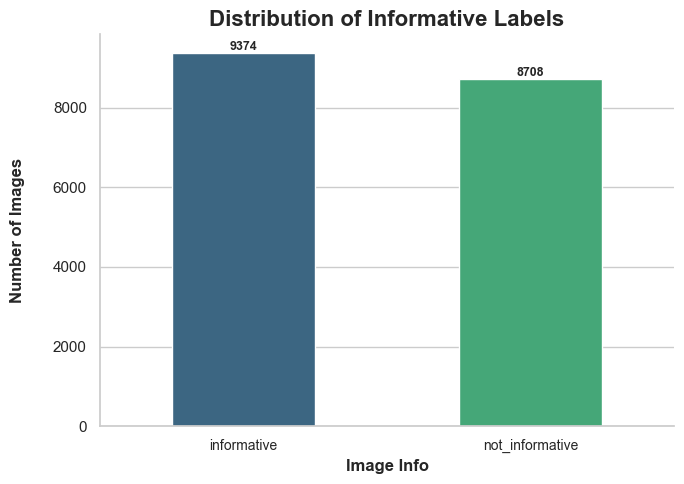

In [14]:
plot_label_distribution(df, "image_info", "Distribution of Informative Labels")

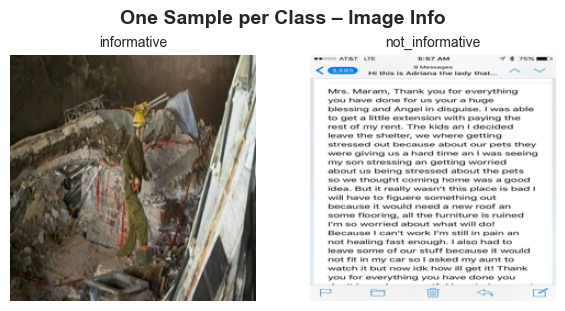

In [15]:
show_one_image_per_label(df, "image_info")

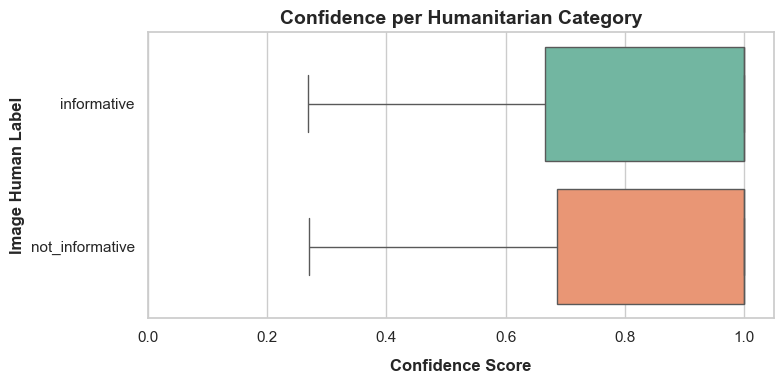

In [16]:
plot_confidence_boxplot(df, "image_info", "image_info_conf", "Confidence per Image Info Label")

## Task 2 - Humanitarian categories

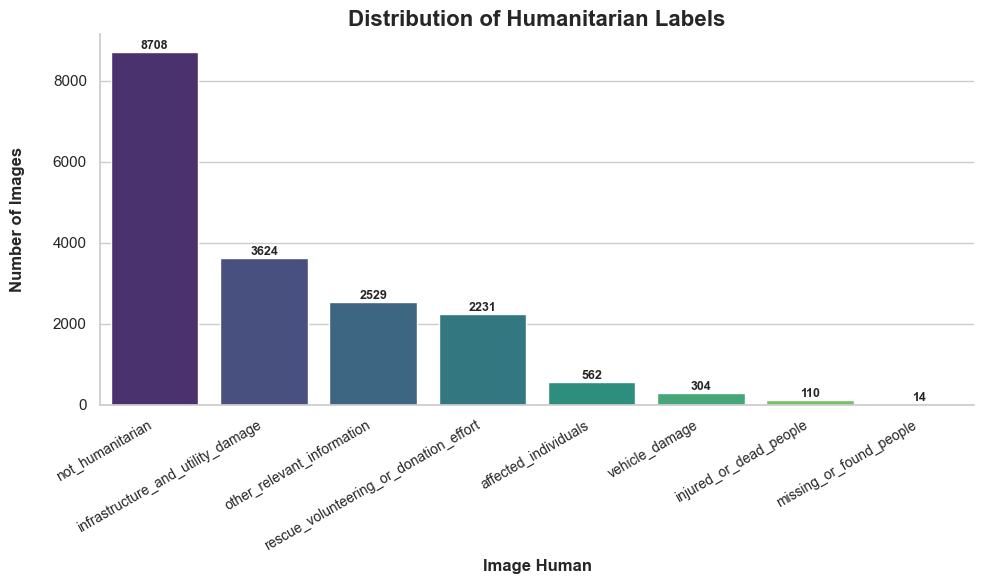

In [17]:
plot_label_distribution(df, "image_human", "Distribution of Humanitarian Labels")

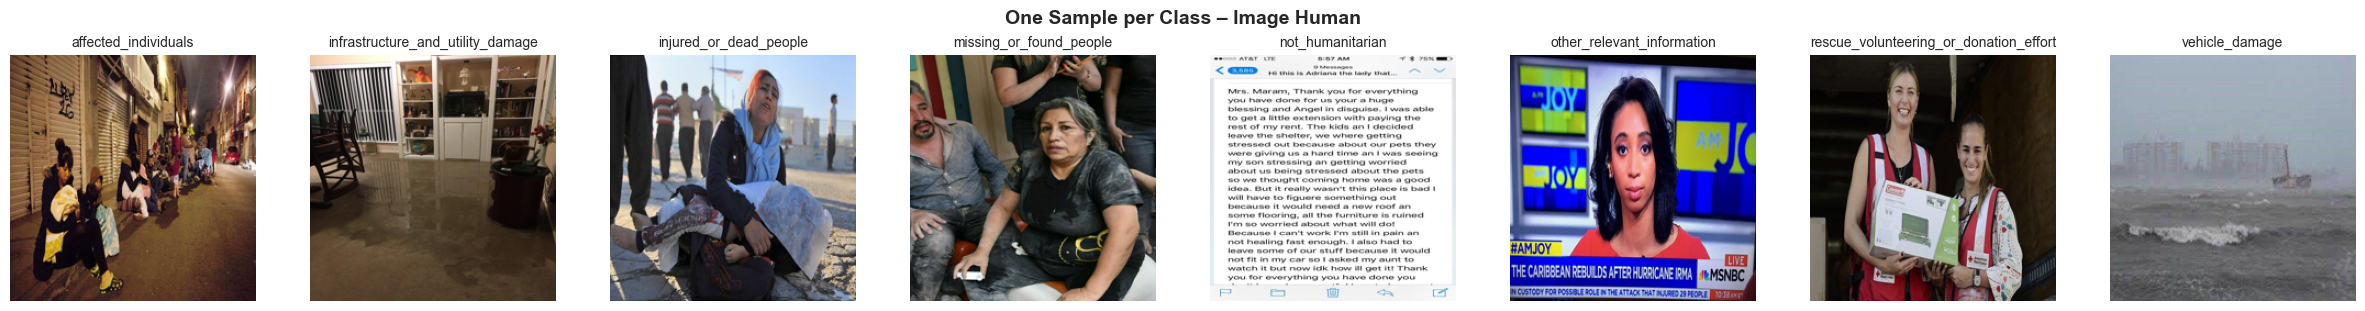

In [18]:
show_one_image_per_label(df, "image_human")

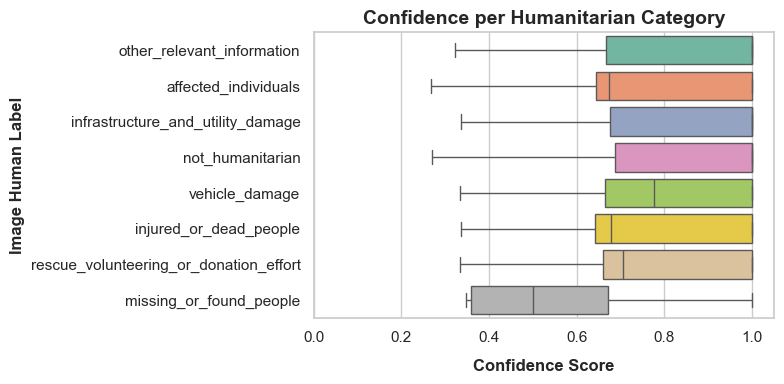

In [19]:
plot_confidence_boxplot(df, "image_human", "image_human_conf", "Confidence per Humanitarian Category")

## Task 3 - Damage severity assessment

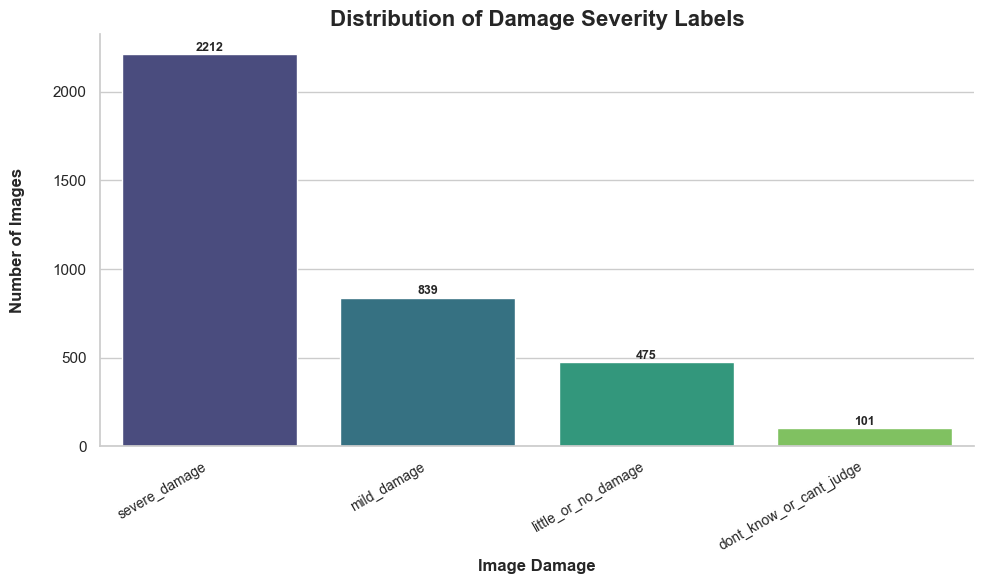

In [20]:
plot_label_distribution(df, "image_damage", "Distribution of Damage Severity Labels")

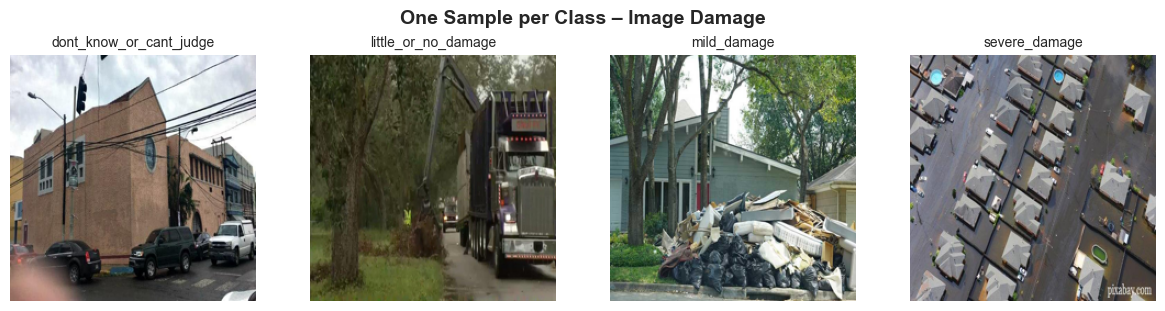

In [21]:
show_one_image_per_label(df, "image_damage")

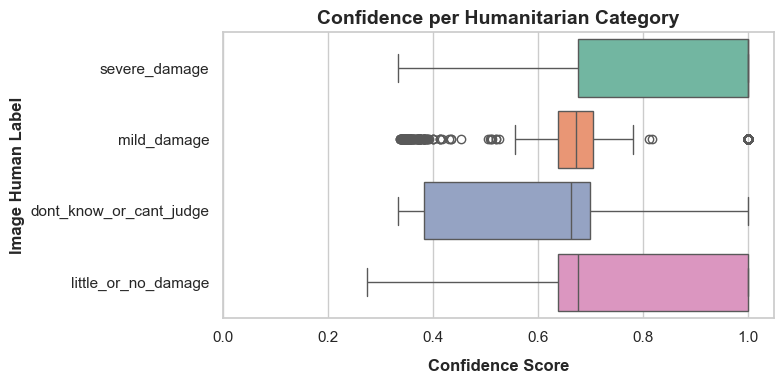

In [22]:
plot_confidence_boxplot(df, "image_damage", "image_damage_conf", "Confidence per Image Info Label")

## Controllo Immagini Duplicate
Avere immagini duplicate all'interno del dataset può portare a delle metriche non realistiche / falsate una volta allenati i modelli, in quanto quest'ultimi potrebbero ricevere in fase di prediction, un'immagine già visualizzata durante la fase di training. 
Non è solo un problema di metriche, ma anche di generalizzazione, infatti, se il modello dovesse vedere più volte un immagine durante la fase di training, il modello potrebbe adattarsi troppo a quella scena e imparare pattern non importanti / generalizzabili. 

### Controllo senza Hashing
Di conseguennza, inizialmente adotiamo un controllo leggero, verificando se ci sono semplicemente delle immagini che hanno lo stesso path o id.


In [61]:
duplicates_path = df[df.duplicated("image_path")]
duplicates_image_id = df[df.duplicated("image_id")]

print(f"{str(len(duplicates_path))} immagini con path duplicato")
print(f"{str(len(duplicates_image_id))} immagini con id duplicato")

0 immagini con path duplicato
0 immagini con id duplicato


Il controllo è andato a buon fine, non ci sono immagini con lo stesso image_path o image_id. Ma questo non esclude che la duplicazione delle immagini si manifesti in altri modi, infatti, potrebbero esserci immagini uguali, che però sono state mappate con id e path differenti. Questo scenario non può essere rilevato con un semplice controllo dei duplicati, ma bisognerebbe esplorare le singole immagini per capire se esistono duplicati.

### Controllo con Hashing
Un modo per verificare se ci sono immagini duplicate, ma con path e id diverso è quello di utilizzare una funzione di hashing. In questo caso, non ci concentriamo più su path e id, ma sulle immagini direttamente. 
Le immagini infatti, verranno date in input ad una funzione di hashing che effettua delle trasformazioni all'immagine per creare e restituire un valore di hash.
**L'aspetto fondamentale è che se si da in input più volte un'immagine identica, la funzione restituirà sempre lo stesso valore di hash, così facendo, sarà possibile sapere se ci sono immagini duplicate all'interno del dataset**.

Calcoliamo il valore di hash di ogni immagine del dataset:

In [62]:
warnings.filterwarnings("ignore", category=UserWarning, module="PIL.Image")

# Calcolo dell'hash visivo per ogni immagine
df["img_hash"] = df["image_path"].apply(
    lambda path: imagehash.phash(Image.open("../" + path))
)

print(f"{len(df['img_hash'])} images' hash calculated")

18082 images' hash calculated


Adesso verifichiamo se ci sono delle immagini che hanno lo stesso valore di hash

In [65]:
# Conta i duplicati visivi
n_duplicates = df["img_hash"].duplicated().sum()

# Filtra solo gli hash duplicati
dupe_counts = df["img_hash"].value_counts()
dupe_counts = dupe_counts[dupe_counts > 1]

n_duplicated_images = dupe_counts.sum()
totoal_images = df.shape[0]
percentage_duplicates = (n_duplicated_images / totoal_images) * 100

print(f"Number of visually duplicate images: {n_duplicates}")
print(f"Total duplicated image instances: {n_duplicated_images} ({percentage_duplicates:.2f}% of the entire dataset)")
print(f"Number of unique duplicate hashes: {len(dupe_counts)}")
print("\nTop 10 most duplicated images (by hash):")
print(dupe_counts.head(10))

Number of visually duplicate images: 728
Total duplicated image instances: 1222 (6.76% of the entire dataset)
Number of unique duplicate hashes: 494

Top 10 most duplicated images (by hash):
img_hash
ad0f87397ae0d078    34
ea2c85d37a2c8c3e    33
96ca4c9569b65b54     9
d0525e312bad8fa9     8
b1670b388f3e9313     8
c0c73f3cc1c37a34     7
9e69699261ce269e     7
9d70f1d1c881d2ed     7
fb03812bac7e3a85     6
aec9c92609cd98f6     6
Name: count, dtype: int64


Nonostante da una prima analisi sembrasse che il dataset non presentasse duplicati, una volta controllati i valori hash si sono presentanti un numero notevole di duplicati. Nell'output precedente è possibile conoscere:
- Il numero di immagini che risultano duplicate
- Il numero totale di immagini coinvolte
- Il numero di valori hash duplicati
- La top 10 delle immagini più duplicate, con alcune immagini che addirittura supera la decina.

## Controllo Delle immagini duplicate
per verificare che le immagini siano realmente duplicate, e che non si tratta di un errore della funzione di hash, eseguiamo un controllo aggiuntivo, visualizzando direttamente le immagini che risultano essere duplicate. 

In [67]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

df["img_hash_str"] = df["img_hash"].astype(str)
dupes = df[df.duplicated("img_hash_str", keep=False)]
df_grouped = dupes.groupby("img_hash_str").size().reset_index(name='count')

# Visualizzo i gruppi di duplicati
for hash_val, group in dupes.groupby("img_hash_str"):
    if len(group) > 1:
        print(f"\nHash: {hash_val} – {len(group)} immagini")
        display(group[["tweet_id", "image_id", "image_path", "img_hash"]].head(len(group)))
        break # togli il break per vedere tutti



Hash: 8000000000000000 – 3 immagini


,tweet_id,image_id,image_path,img_hash
5840,909777730924896256,909777730924896256_0,data_image/hurricane_harvey/18_9_2017/909777730924896256_0.jpg,8000000000000000
8490,909839409222230017,909839409222230017_0,data_image/hurricane_irma/18_9_2017/909839409222230017_0.jpg,8000000000000000
10102,910197668680540160,910197668680540160_0,data_image/hurricane_irma/19_9_2017/910197668680540160_0.jpg,8000000000000000


Rispetto prima, stampiamo anche ulteriori informazioni dell'immagine, come path, id e il tweet di appartenenza. 
Anallizando, si può notare come le immagini hanno effettivamente lo stesso hash, ma, path, image_id e tweet_id diverso. 
Di conseguenza, senza l'aggiunta dell'hash, non sarebbe stato possibile individuare questi duplicati (avendo tutti i valori diversi).

In [69]:
def show_duplicate_images_by_hash(df, hash_value, image_root="data_image", resize_to=(224, 224)):
    # Seleziona immagini con hash uguale
    group = df[df["img_hash"] == hash_value]
    image_paths = group["image_path"].tolist()
    n = len(image_paths)

    # Plot
    fig, axes = plt.subplots(1, n, figsize=(n * 3, 3))
    fig.suptitle(f"Duplicate images for hash: {hash_value}", fontsize=12, fontweight="bold")

    for i, path in enumerate(image_paths):
        try:
            img = Image.open("../" + path)
            if img.mode in ("P", "LA"):
                img = img.convert("RGBA")
            img = img.resize(resize_to)

            ax = axes[i] if n > 1 else axes
            ax.imshow(img)
            ax.axis('off')
            ax.set_title(os.path.basename(path), fontsize=8)
        except Exception as e:
            print(f"Error loading image {path}: {e}")

    plt.tight_layout()
    plt.show()


Per verificare se si tratta realmente di immagini duplicate, e che non sia stato di nuovo la funzione di hash a sbagliare, definisco una funzione per stampare un banch di immagini con lo stesso valore di hash.

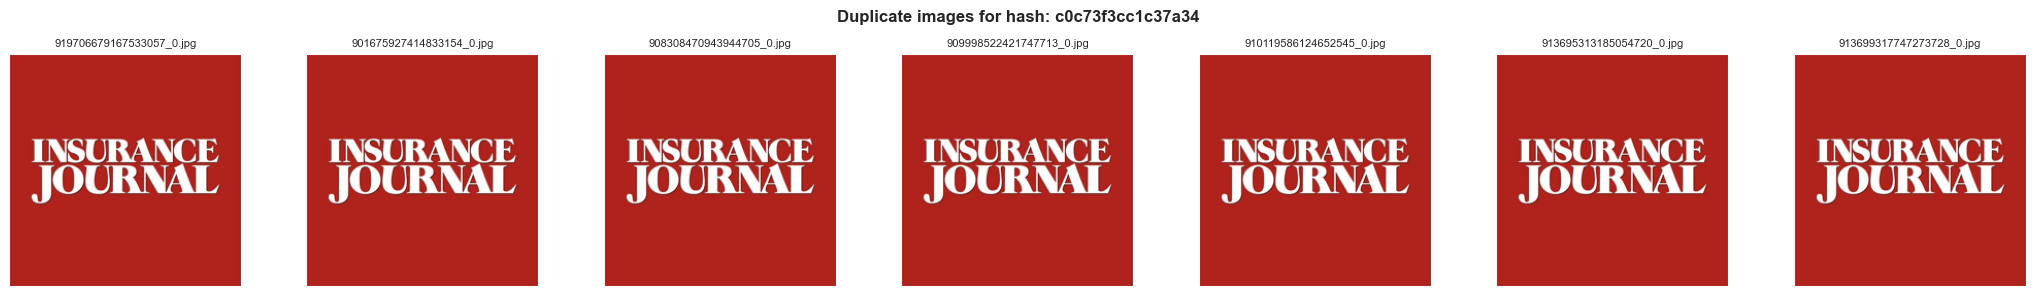

In [70]:
# Prendi il primo hash duplicato
dupe_hashes = df["img_hash"][df.duplicated("img_hash", keep=False)]
first_hash = dupe_hashes.value_counts().index[5]

show_duplicate_images_by_hash(df, first_hash)


Una volta stampate le immagini con lo stesso valore di hash, la situazione si chiarisce ancor di più: infatti, le immagini, sono realmente duplicate.
Questo vuol dire che la funzione di hashing ha funzionato correttamente, e che quindi sono presenti un numero significativo di immagini che si ripetono nel dataset, ma che hanno metadati completamente differenti tra di loro.

Per rendere la situazione piu chiara, definiamo un grafico che mostra il numero di unità coinvolte.

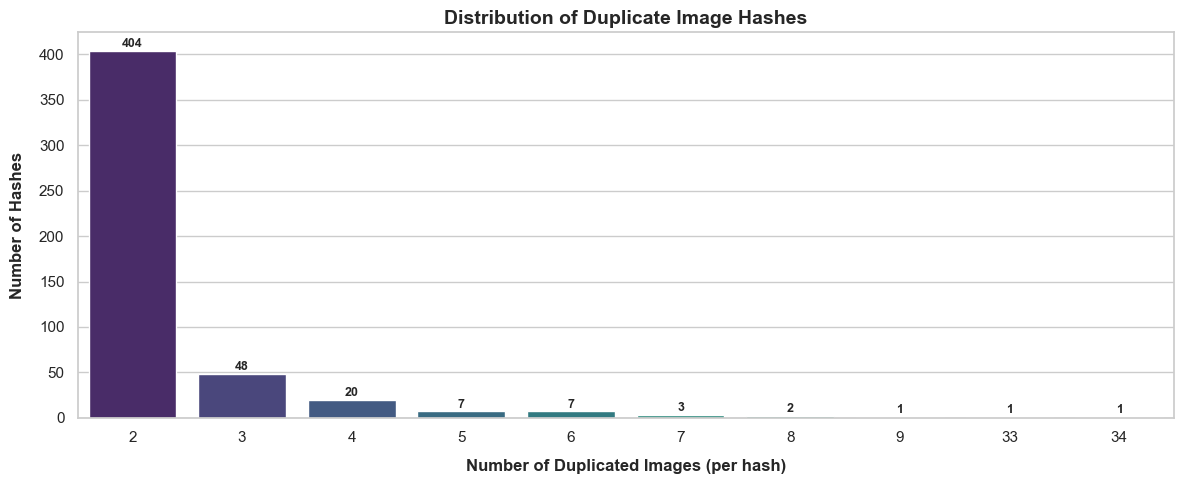

In [72]:
# Filtra solo gli hash duplicati
dupe_counts = df["img_hash"].value_counts()
dupe_counts = dupe_counts[dupe_counts > 1]

# Calcola distribuzione: quanti hash hanno N duplicati
counts_per_group_size = dupe_counts.value_counts().sort_index()

# Plot
plt.figure(figsize=(12, 5))

sns.set(style="whitegrid")  # stile seaborn
warnings.filterwarnings("ignore", category=FutureWarning)
ax = sns.barplot(x=counts_per_group_size.index, y=counts_per_group_size.values, palette="viridis")

plt.title("Distribution of Duplicate Image Hashes", fontsize=14, fontweight="bold")
plt.xlabel("Number of Duplicated Images (per hash)", fontsize=12, fontweight="bold", labelpad=10)
plt.ylabel("Number of Hashes", fontsize=12, fontweight="bold", labelpad=10)
plt.xticks(rotation=0)

# Aggiungi etichette sopra le barre
for i, value in enumerate(counts_per_group_size.values):
    ax.text(i, value + 1, str(value), ha='center', va='bottom', fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()


- L'asse delle X indica quante volte quel valore di hash si duplica (quante immagini sono associate a quel valore di hash)
- L'asse delle Y indica il numero di Hashes duplicati

Quindi data una coppia (x,y), quest'ultima indica che  ci sono Y valori di hash che si ripetono X volte.
Es: data la coppia (34,1), vuol dire che c'è un valore di hash che si ripete 34 volte -> immagine che si ripete 34 volte nel dataset

In [75]:
def show_duplicate_grid_by_hash(df, hash_value, image_root="data_image", resize_to=(224, 224)):
    # Filtra le immagini con l'hash dato
    group = df[df["img_hash"] == hash_value]
    image_paths = group["image_path"].tolist()
    n = len(image_paths)

    if n == 0:
        print("No images found with this hash.")
        return

    # Calcola righe e colonne per la griglia
    n_cols = min(n, 5)  # max 5 per riga
    n_rows = math.ceil(n / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
    fig.suptitle(f"{n} images with hash: {hash_value}", fontsize=14, fontweight="bold", y=1.0)
    axes = axes.flatten() if n > 1 else [axes]

    for i, path in enumerate(image_paths):
        try:
            img = Image.open("../" + path)
            if img.mode in ("P", "LA"):
                img = img.convert("RGBA")
            img = img.resize(resize_to)

            axes[i].imshow(img)
            axes[i].axis("off")
            axes[i].set_title(os.path.basename(path), fontsize=8, pad=20)
        except Exception as e:
            print(f"Error loading {path}: {e}")
            axes[i].axis("off")
            axes[i].set_title("Error", fontsize=8)

    # Disabilita assi inutilizzati
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


definisco una funzione di plotting che mostra in una griglia tutte le immagini che hanno il valore di hash passato in input.
Così facendo è possibile verificare le immagini di un valore di hash preciso.
Es: verificare se il valore di hash con il maggior numero di duplicati contiene davvero tutte immagini duplicate

Testiamo la funzione su un valore di hash che rientra nella top 10 restituia dai notebook precedenti:

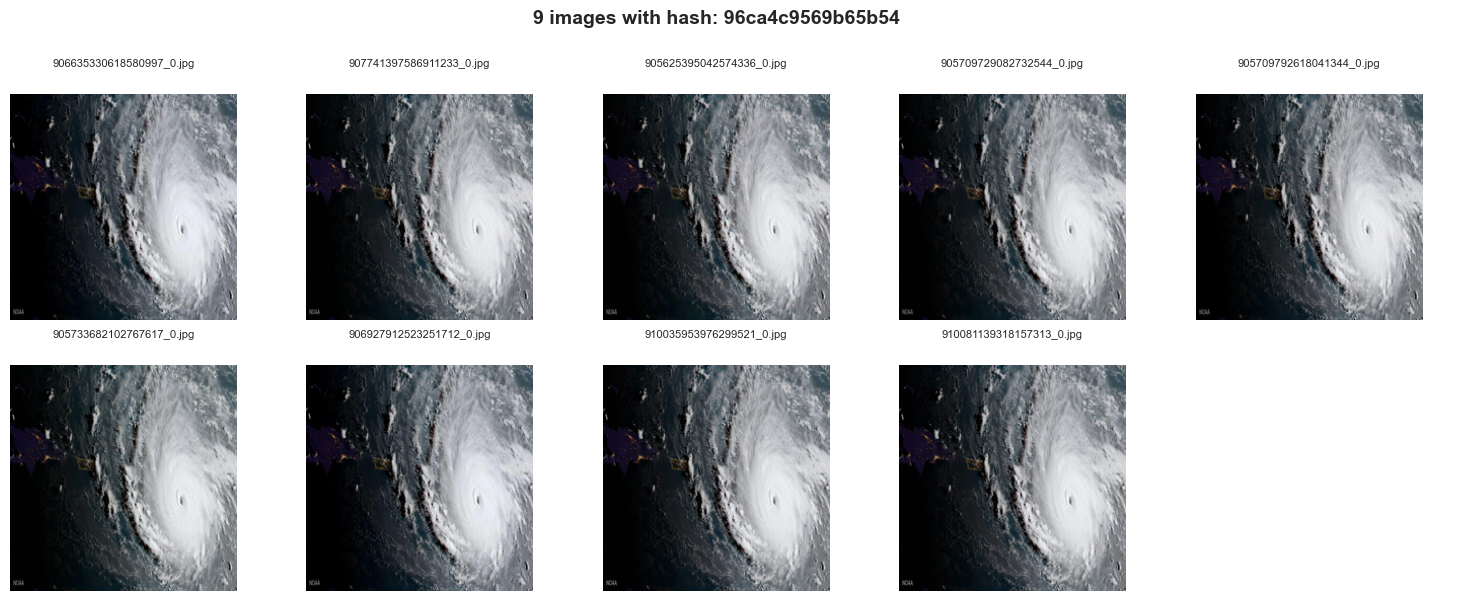

In [76]:
# Supponiamo che tu abbia l'hash in formato stringa
hash_string = "96ca4c9569b65b54"

# Converti la stringa in oggetto ImageHash
hash_value = imagehash.hex_to_hash(hash_string)

# Ora puoi passarlo alla funzione
show_duplicate_grid_by_hash(df, hash_value)

Anche dopo questo test, riotteniamo la conferma che la funzione di hashing ha lavorato correttamente, e che quindi, sono presenti delle immagini duplicate all'interno del dataset, ma, con metadati completamente differenti, rendendo difficile l'identificazione in dei primi controlli meno approfonditi.

## Label Analysis sulle immagini duplicate
adesso, lavoriamo sulle label delle immagini duplicate, per capire inizialmente quali e quante label hanno immagini duplicate e successivamente, verificare se sono presenti dei conflitti tra label, cioè, stesse immagini ma con valori di label differenti.

Partiamo col definire i plot di quali label presentano immagini duplicate, e quante sono le immagini totali coinvolte per ogni valore di label:

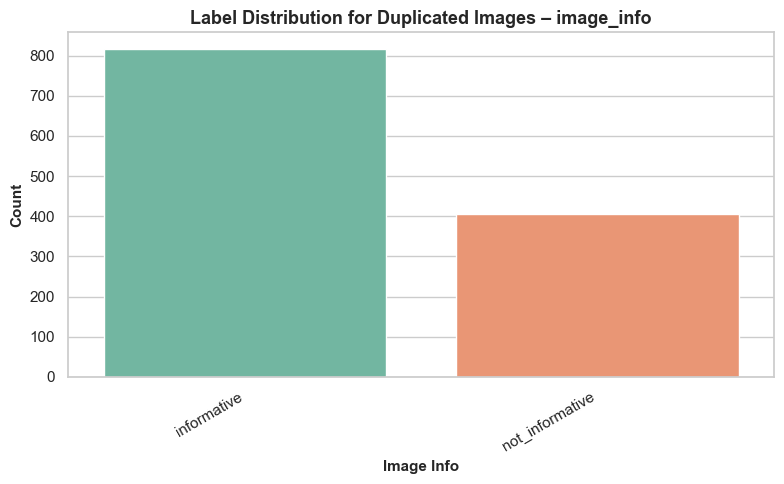

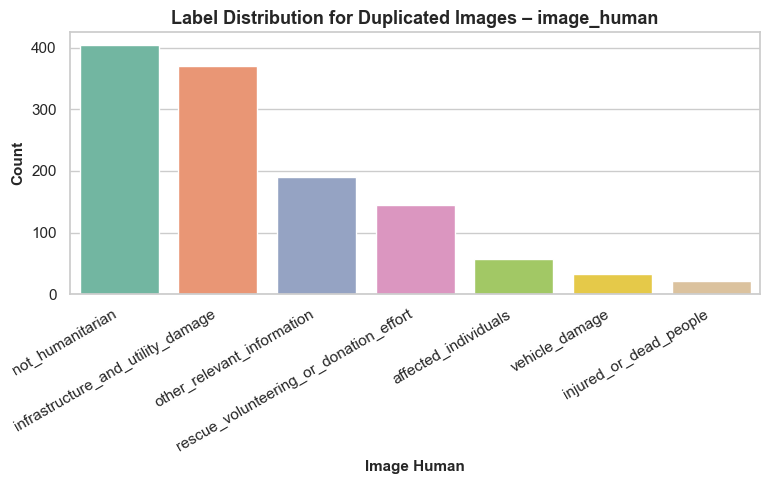

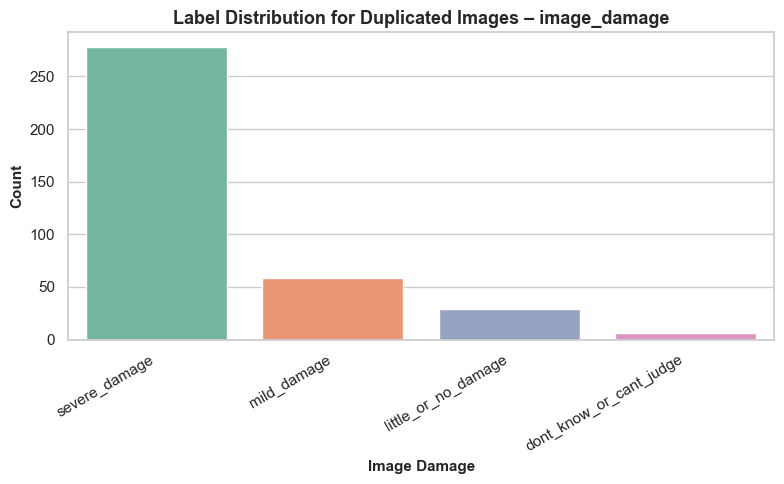

In [78]:
def plot_duplicate_label_distributions(df, label_cols):
    sns.set(style="whitegrid")  # stile seaborn
    warnings.filterwarnings("ignore", category=FutureWarning)
    duplicates_df = df[df.duplicated("img_hash", keep=False)]

    for label_col in label_cols:
        plt.figure(figsize=(8, 5))
        sns.countplot(data=duplicates_df, x=label_col, order=duplicates_df[label_col].value_counts().index, palette="Set2")
        plt.title(f"Label Distribution for Duplicated Images – {label_col}", fontsize=13, fontweight="bold")
        plt.xlabel(label_col.replace("_", " ").title(), fontsize=11, fontweight="bold")
        plt.ylabel("Count", fontsize=11, fontweight="bold")
        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()
        plt.show()

# Esempio d'uso
plot_duplicate_label_distributions(df, ["image_info", "image_human", "image_damage"])


**Analizzando i grafici tutte le label, di qualsiasi task, presentano delle immagini duplicate.**

Adesso facciamo un controllo più approfondito: verificare se ci sono immagini duplicate che presentano valori differenti nelle label (conflitti).

In [82]:
def label_conflict_report(df, label_col):
    #df["img_hash_str"] = df["img_hash"].astype(str)

    conflict_hashes = (
        df[df.duplicated("img_hash_str", keep=False)]
        .groupby("img_hash_str")[label_col]
        .nunique()
        .reset_index()
        .query(f"{label_col} > 1")
    )
    return conflict_hashes

# Esegui per ogni task
conf_info = label_conflict_report(df, "image_info")
conf_human = label_conflict_report(df, "image_human")
conf_damage = label_conflict_report(df, "image_damage")
hashes_conf = set()

hashes_conf.update(conf_info["img_hash_str"].unique().tolist())
hashes_conf.update(conf_human["img_hash_str"].unique().tolist())
hashes_conf.update(conf_damage["img_hash_str"].unique().tolist())

# Riepilogo
print(f"Conflicting hashes (image_info): {len(conf_info)}")
print(f"Conflicting hashes (image_human): {len(conf_human)}")
print(f"Conflicting hashes (image_damage): {len(conf_damage)}")
print(f"Total numbers of unique Conflictiùng hashes {len(hashes_conf)}:")
print(hashes_conf)


Conflicting hashes (image_info): 43
Conflicting hashes (image_human): 87
Conflicting hashes (image_damage): 40
Total numbers of unique Conflictiùng hashes 126:
{'901d47763ad9a566', '80d47f43786a26eb', '8a42fc2ba87baa69', 'f6c89b33f02585a3', 'c3cf1c5833c34e5c', 'a3368563de1bfc01', 'befac191548dac16', 'd1c3cca83632972f', 'b6a26049b35be399', '82ade3f4c574711a', '8e6bb26ca4c9a25d', '80734de64ac55bad', 'ab92b933e84ca959', '9c9f1906c294bfa3', 'c09f63e49ec330b3', 'ba34c6c1293be65a', '9c1c0c1c9d9d1c7f', 'a4efba708e328f82', '888fc383b4d3696d', 'cb096b9c3497dc26', '887b75691ba15a1d', 'c971c63b1f3e222c', 'dae50ab474d9a58a', 'a8f8ad851e685772', '8debd08fb0f00ef0', 'cc5554a355dd81d3', 'ba3edd9592d18143', 'eb3513c6ca32b4e1', 'f28e9aa98b96a730', '96876eca6be09469', '8ff1c50ff00cee90', 'e9d6a634694dc817', 'c5633295df32219b', 'fa4cc5722e8965a6', '9087dab2cec1fa4a', '9e257b2565716465', 'c3c44a6d9a0de4db', '81fde0865f4af0d8', 'ca2ad94dd67621d1', 'dccc81e7a7270786', '9f74425bed04307b', '8a35f5da0a252fd8',

La funzione restituisce il numero di immagini che presentano dei conflitti nelle label. Il numero totale è minore rispetto alla somma delle singole label perchè ci sono degli hash che presentano conflitti su più label.

La funzione restituisce tutti i valori di hash che hanno almeno un conflitto sulle label, in modo da poter visualizzare manualmente le immagini e verificare se effettivamente le label assegnate hanno valori differenti.

Definiamo un plot che ci mostra quali e per quante volte le label presentano dei conflitti:

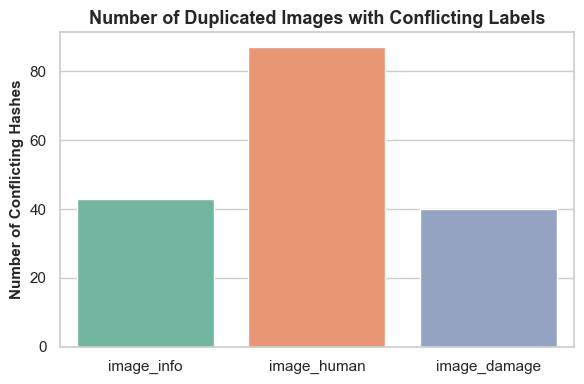

In [84]:
conflict_counts = {
    "image_info": len(conf_info),
    "image_human": len(conf_human),
    "image_damage": len(conf_damage)
}

plt.figure(figsize=(6, 4))
sns.set(style="whitegrid")  # stile seaborn
warnings.filterwarnings("ignore", category=FutureWarning)

sns.barplot(x=list(conflict_counts.keys()), y=list(conflict_counts.values()),palette="Set2")
plt.title("Number of Duplicated Images with Conflicting Labels", fontsize=13, fontweight="bold")
plt.ylabel("Number of Conflicting Hashes", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()


La label che è coinvolta nella maggior parte dei conflitti è image_human.

Passiamo ad un controllo visivo, definiamo una funzione che dato un hash in input, mostra tutte le immagini con quell'hash, con la presenza delle proprie label, per verificare se effettivamente gli sono state associati valori distinti, nonostante l'immagine non cambiasse.

In [86]:
def show_duplicate_grid_with_labels(df, hash_value, image_root="data_image", resize_to=(224, 224)):
    # Filtra immagini con l'hash fornito
    group = df[df["img_hash_str"] == hash_value]
    image_paths = group["image_path"].tolist()
    n = len(image_paths)

    if n == 0:
        print("No images found with this hash.")
        return

    # Trova la label più comune per ogni task
    def most_common(series):
        return Counter(series).most_common(1)[0][0]

    common_info = most_common(group["image_info"])
    common_human = most_common(group["image_human"])
    common_damage = most_common(group["image_damage"])

    # Griglia
    n_cols = min(n, 5)
    n_rows = math.ceil(n / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
    axes = axes.flatten() if n > 1 else [axes]
    fig.suptitle(f"Duplicate images with hash: {hash_value}", fontsize=14, fontweight="bold")

    for i, (idx, row) in enumerate(group.iterrows()):
        ax = axes[i]
        image_path = "../" + row["image_path"]
        try:
            img = Image.open(image_path)
            if img.mode in ("P", "LA"):
                img = img.convert("RGBA")
            img = img.resize(resize_to)

            ax.imshow(img)
            ax.axis('off')

            # Costruzione titolo con colori diversi se c'è disaccordo
            def label_text(label, common):
              return f"{label}" if label == common else f"$\\bf{{{label}}}$"

            label_info = (
                f"Info: {label_text(row['image_info'], common_info)}\n"
                f"Human: {label_text(row['image_human'], common_human)}\n"
                f"Damage: {label_text(row['image_damage'], common_damage)}"
            )

            ax.set_title(label_info, fontsize=9)
            ax.text(0.5, -0.04, row["image_path"], fontsize=7, ha="center", va="top", transform=ax.transAxes)
            plt.subplots_adjust(hspace=0.6)  # o hspace=0.7 per ancora più margine

        except Exception as e:
            print(f"Error loading image {image_path}: {e}")
            ax.axis('off')
            ax.set_title("Error", fontsize=9)

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
    display(group[["image_info", "image_human", "image_damage", "img_hash", "image_path"]])

Proviamo la funzione dandogli in input un valore di hash restituito dalle funzioni precedenti che ha mostrato tutti gli hash coinvolti in un conflitto:

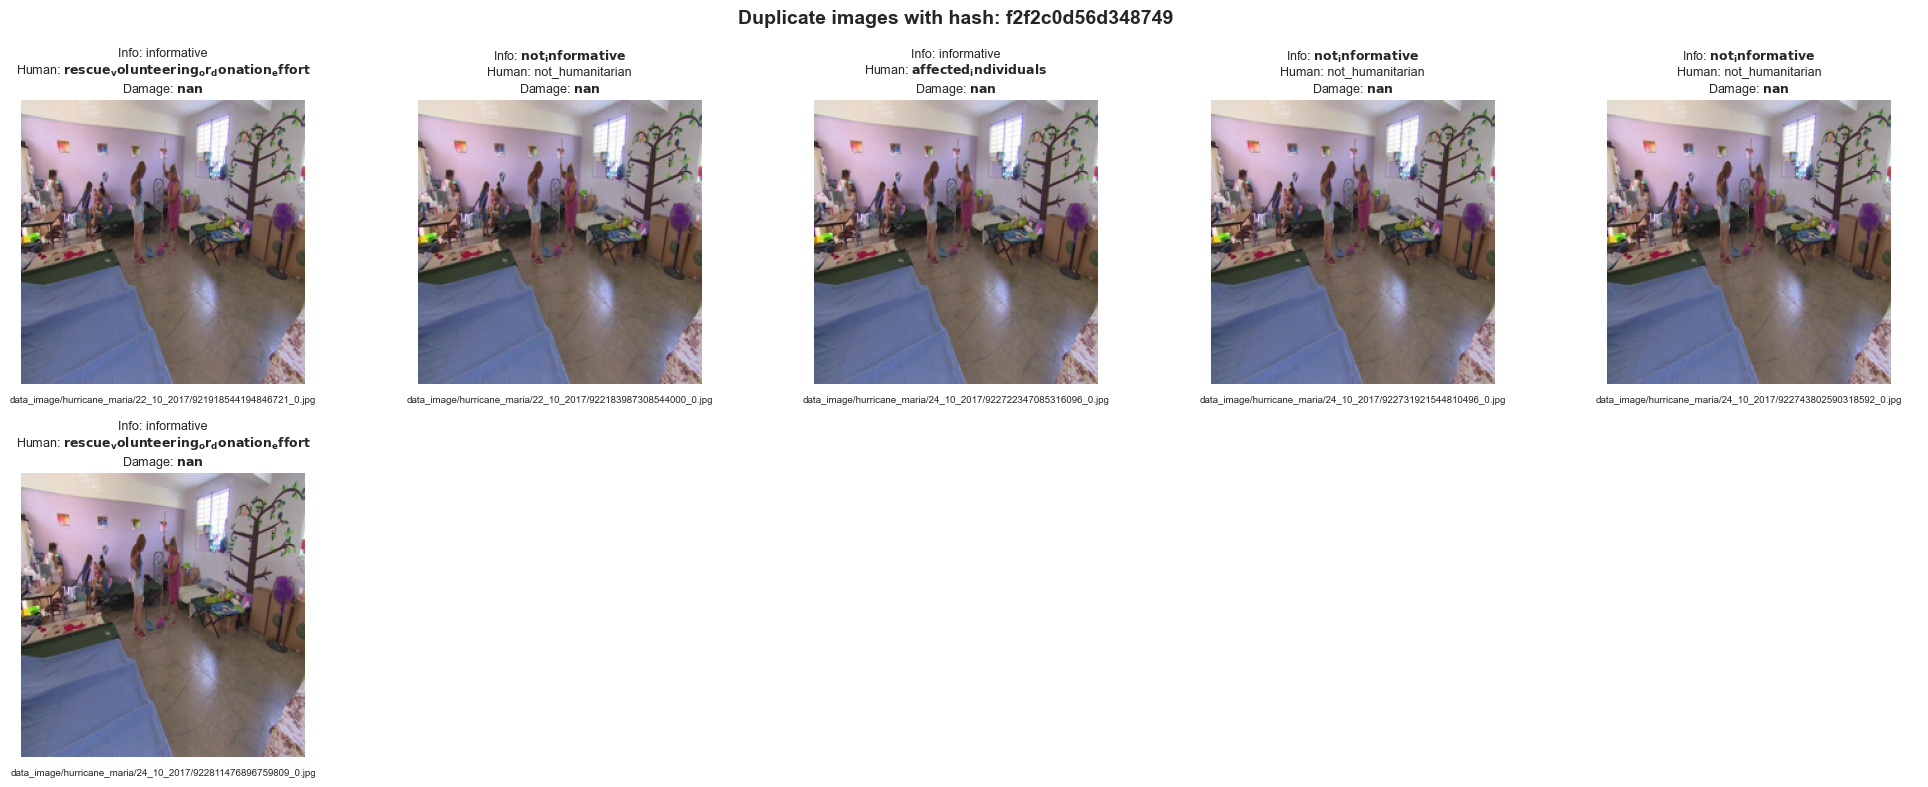

,image_info,image_human,image_damage,img_hash,image_path
13542,informative,rescue_volunteering_or_donation_effort,NaN,f2f2c0d56d348749,data_image/hurricane_maria/22_10_2017/921918544194846721_0.jpg
13635,not_informative,not_humanitarian,NaN,f2f2c0d56d348749,data_image/hurricane_maria/22_10_2017/922183987308544000_0.jpg
13896,informative,affected_individuals,NaN,f2f2c0d56d348749,data_image/hurricane_maria/24_10_2017/922722347085316096_0.jpg
13898,not_informative,not_humanitarian,NaN,f2f2c0d56d348749,data_image/hurricane_maria/24_10_2017/922731921544810496_0.jpg
13907,not_informative,not_humanitarian,NaN,f2f2c0d56d348749,data_image/hurricane_maria/24_10_2017/922743802590318592_0.jpg
13920,informative,rescue_volunteering_or_donation_effort,NaN,f2f2c0d56d348749,data_image/hurricane_maria/24_10_2017/922811476896759809_0.jpg


In [87]:
# Supponiamo che tu abbia l'hash in formato stringa
conflicting_hash_value = "f2f2c0d56d348749"

# Esempio con uno degli hash in conflitto
show_duplicate_grid_with_labels(df, conflicting_hash_value)

Analizzando le label delle immagini sono presenti effettivamente dei conflitti, in questo caso, anche su piu label.

## Controllo tweet delle immagini duplicate
Considerando le righe del dataset che contengono immagini duplicate, verifico se i tweet associati sono diversi o sono coinvolti anche loro nella duplicazione

In [89]:
# Gruppo per 'img_hash_str' e conto i testi unici per ogni gruppo
grp = df.groupby('img_hash_str')['tweet_text'].nunique()

# Prendo solo quelli con più di un testo diverso
hashes_with_conflict = grp[grp > 1].index

# Filtro il dataframe originale per tenere solo questi
df_conflicting = df[df['img_hash_str'].isin(hashes_with_conflict)]
n_images = len(df_conflicting["img_hash_str"].unique())

print(f"{str(n_images)} immagini duplicate hanno diversi testi di tweet")
df_conflicting[["tweet_id", "tweet_text", "img_hash_str"]].sort_values(by="img_hash_str").head(20)


482 immagini duplicate hanno diversi testi di tweet


,tweet_id,tweet_text,img_hash_str
5840,909777730924896256,"Like Harvey, Retirement Plans Can Make Loans, Hardship Distributions to #retirement plan https://t.co/kqv9jMwWvp https://t.co/UjsVV564uH",8000000000000000
10102,910197668680540160,Who Gets Hit by Mortgage Losses in Harvey and Irma Areas? https://t.co/OCXyKmXAAb #WolfStreet https://t.co/CSBjzL5EAA,8000000000000000
8490,909839409222230017,Reload Miami Conference -- Irma Update!! https://t.co/P6KweHplm0 https://t.co/DQRG7sRBEY,8000000000000000
5289,908168392716234753,Harvey survivor assistance lines https://t.co/KcHTpw3RjT https://t.co/7Lyod9FQxV,802b2deaca2e5e7a
3823,905900370412441600,Where to report scammers preying on Harvey victims https://t.co/wdtfEFABHb https://t.co/U2Ln7Pt1qR,802b2deaca2e5e7a
1919,901814144680255488,business: FEMA is prepared to be on Harvey recovery for years https://t.co/OMcEVkLIzo https://t.co/jWv2prYXoc https://t.co/N4N2gu14jg,8072fea0985a5ed7
1929,901822511750406144,Flooding Replaces High Wind as Harvey Threat to Texas Gulf Coast https://t.co/kEt9TacY3c #fintech #finance https://t.co/ySZIvOsNsA,8072fea0985a5ed7
11934,913176642889109504,Facebook is sending employees to Puerto Rico to try and help get the territory back online https://t.co/cScKgKA9ta https://t.co/oTKPTtGtEh,80734de64ac55bad
11904,913129211417829378,How we would cover Trump's handling of Puerto Rico if it were happening in another country https://t.co/LMO7RC47mp https://t.co/Qn9U8taUvI,80734de64ac55bad
15496,930457005550112770,Iran pledges swift aid after major quake kills 400 https://t.co/HGEzcCnpBq https://t.co/Ij7LHbV3p4,80b4be4b5656956d


In [93]:
print(df.shape)
print(df.columns)

(18082, 18)
Index(['tweet_id', 'image_id', 'text_info', 'text_info_conf', 'image_info',
       'image_info_conf', 'text_human', 'text_human_conf', 'image_human',
       'image_human_conf', 'image_damage', 'image_damage_conf', 'tweet_text',
       'image_url', 'image_path', 'disaster_type', 'img_hash', 'img_hash_str'],
      dtype='object')


In [94]:
df = df.drop(columns=['img_hash'])
print("Colonna img_hash rimossa dal dataframe.")
print(df.shape)
print(df.columns)

Colonna img_hash rimossa dal dataframe.
(18082, 17)
Index(['tweet_id', 'image_id', 'text_info', 'text_info_conf', 'image_info',
       'image_info_conf', 'text_human', 'text_human_conf', 'image_human',
       'image_human_conf', 'image_damage', 'image_damage_conf', 'tweet_text',
       'image_url', 'image_path', 'disaster_type', 'img_hash_str'],
      dtype='object')


In [95]:
annotations_file_hash = os.path.join(data_dir, "annotations_with_hash.tsv")

df.to_csv(annotations_file_hash, sep='\t', index=False)